In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools
# from scipy.stats import chi2_contingency
from plotly.subplots import make_subplots
import plotly.express as px
import numpy as np
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import array as arr
import plotly.graph_objects as go
from IPython.display import display, HTML


In [2]:
url = 'https://raw.githubusercontent.com/nlihin/EDA-course/refs/heads/main/datasets/avocado.csv'
df = pd.read_csv(url)
df.head()

,Unnamed: 0,Date,AveragePrice,total_sold,small_sold,large_sold,sma,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,27/12/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,20/12/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,13/12/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,06/12/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,29/11/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [3]:
by_date = df.groupby(['region','year'])[['total_sold']].sum()
by_date



total_sold
region           year             
Albany           2015   4029896.43
                 2016   5264335.59
                 2017   5231581.78
                 2018   1541986.17
Atlanta          2015  23231698.12
...                            ...
West             2018  92477085.01
WestTexNewMexico 2015  41523998.11
                 2016  43807431.60
                 2017  47389589.29
                 2018  11800820.78

[216 rows x 1 columns]

In [4]:
denver_info = df[(df['region']=='Denver') & (df['year']==2016)].copy()
denver_info['total_sold'].mean().round()



435652.0

In [5]:
denver_info['Date'] = pd.to_datetime(denver_info['Date'],format='%d/%m/%Y')
denver_info['month'] = pd.DatetimeIndex(denver_info['Date']).month 

denver_info[denver_info['month'] == 9].agg({'Total Bags': 'sum'})

Total Bags    1744520.91
dtype: float64

In [6]:
denver_info[denver_info['month'] == 9].reset_index()

,index,Unnamed: 0,Date,AveragePrice,total_sold,small_sold,large_sold,sma,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,month
0,3445,13,2016-09-25,1.15,680946.51,135131.95,168060.00,16829.34,360925.22,91074.56,269661.77,188.89,conventional,2016,Denver,9
1,3446,14,2016-09-18,1.02,757358.11,134607.83,198214.42,16328.76,408207.10,87026.05,320842.16,338.89,conventional,2016,Denver,9
2,3447,15,2016-09-11,0.98,791566.05,112292.42,227729.26,14432.98,437111.39,93898.07,342085.54,1127.78,conventional,2016,Denver,9
3,3448,16,2016-09-04,0.91,924278.16,146921.58,254464.01,17239.60,505652.97,83143.66,422509.31,0.00,conventional,2016,Denver,9
4,12570,13,2016-09-25,1.72,12327.94,9350.55,1694.55,8.12,1274.72,1191.60,83.12,0.00,organic,2016,Denver,9
5,12571,14,2016-09-18,1.37,22036.49,10442.96,2216.61,5.80,9371.12,9071.01,300.11,0.00,organic,2016,Denver,9
6,12572,15,2016-09-11,1.40,20741.79,10019.08,2407.87,13.89,8300.95,8044.58,256.37,0.00,organic,2016,Denver,9
7,12573,16,2016-09-04,1.15,25026.47,8810.53,2263.32,275.18,13677.44,11408.72,2268.72,0.00,organic,2016,Denver,9


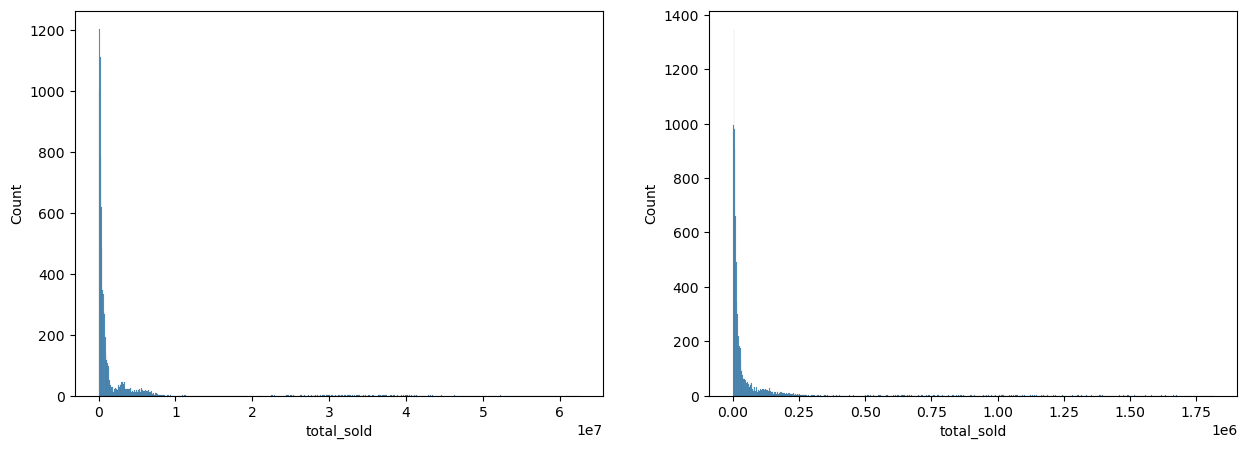

In [7]:
only_conventional = df[df['type']=='conventional']
only_organic = df[df['type']=='organic']

fig,ax  = plt.subplots(1,2, figsize = (15,5))
sns.histplot(data = only_conventional, x='total_sold',ax =ax[0] )
sns.histplot(data = only_organic, x= 'total_sold',ax = ax[1])
plt.show()

<Axes: xlabel='total_sold', ylabel='Count'>

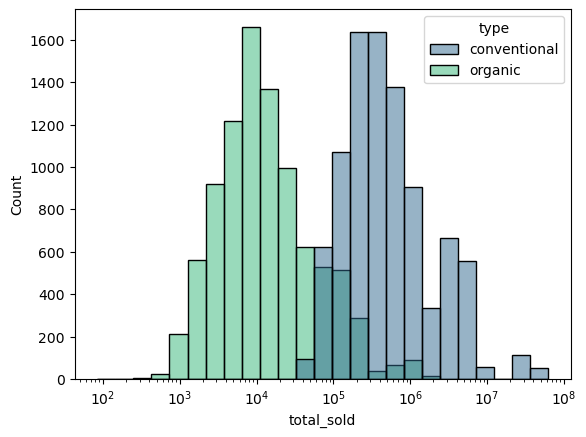

In [20]:
sns.histplot(data=df, x="total_sold", hue= "type", log_scale=True, bins=25,palette='viridis')

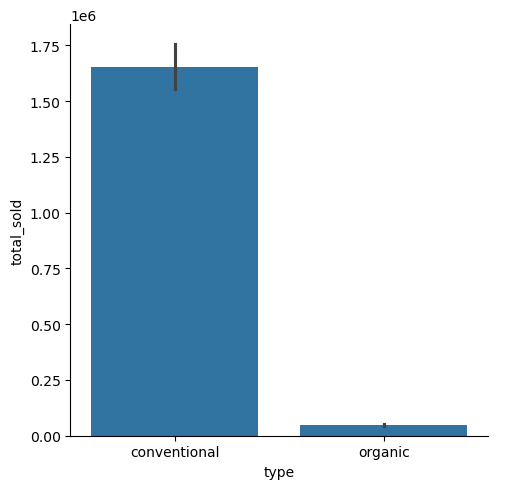

In [36]:
sns.catplot(data=df , x="type", y="total_sold", kind="bar" )

<Axes: >

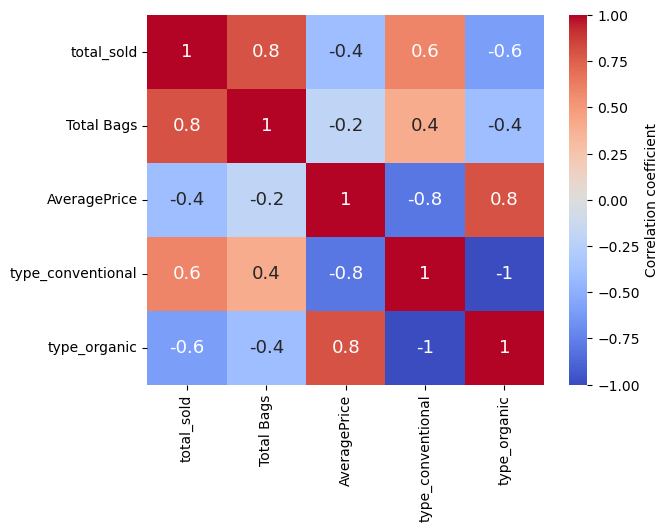

In [67]:
features = ['type','total_sold', 'Total Bags','AveragePrice']

with_corr =pd.get_dummies(df[features]).corr()
correlation_matrix = with_corr.corr(method = 'kendall').round(5)
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm',annot_kws={'size': 13} , xticklabels=with_corr.columns, yticklabels=with_corr.columns, 
            cbar_kws={'label': 'Correlation coefficient'})

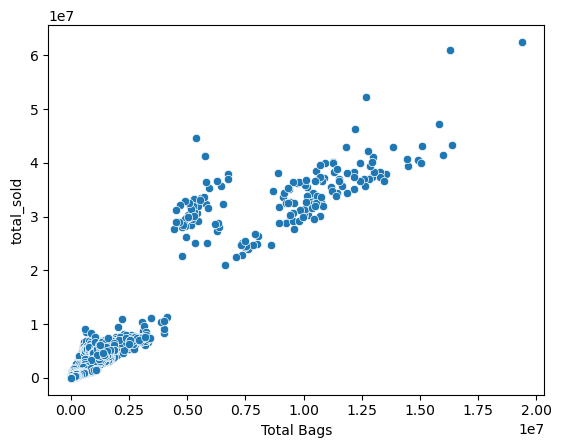

In [69]:
sns.scatterplot(data=df,x='Total Bags',y='total_sold')
plt.show()